# Детекция голосовых дипфейков при помощи моделей классического машинного обучения с использованием композиции спектральных признаков

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import brentq
from scipy.interpolate import interp1d

import librosa

import xgboost

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import optuna

optuna.logging.set_verbosity(optuna.logging.ERROR)

from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore")

## 1. Подготовка данных

In [2]:
DATASET_PATH = "/kaggle/input/russian-speech-deepfake-detection-dataset/russian_sdd_dataset"

In [3]:
train_df = pd.read_csv(os.path.join(DATASET_PATH, 'train.csv'), index_col=0)
test_df = pd.read_csv(os.path.join(DATASET_PATH, 'test.csv'), index_col=0)

In [4]:
def speaker_independent_split(df: pd.DataFrame, val_ratio: float = 0.2) -> tuple[pd.DataFrame, pd.DataFrame]:
    if not 0 <= val_ratio <= 1:
        raise ValueError(f"Invalid val_ratio: {val_ratio}")
        
    df_ = df.copy()
    unique_speakers = df_['spk_id'].unique()

    train_speakers = set(unique_speakers[:int(len(unique_speakers)*(1-val_ratio))])
    val_speakers = set(unique_speakers[int(len(unique_speakers)*(1-val_ratio)): ])

    df_['split'] = df_['spk_id'].apply(lambda x: "train" if x in train_speakers else "val")

    train_df = df_[df_['split'] == "train"]
    val_df = df_[df_['split'] == "val"]

    return train_df, val_df 

In [5]:
train_df, val_df = speaker_independent_split(train_df, val_ratio=0.2)

In [6]:
train_audios = [os.path.join(DATASET_PATH, audio) for audio in train_df['audio']]
val_audios = [os.path.join(DATASET_PATH, audio) for audio in val_df['audio']]
test_audios = [os.path.join(DATASET_PATH, audio) for audio in test_df['audio']]

In [7]:
class FeatureExtractor:
    def __init__(self, n_mfcc: int = 40, features_dim: int = 65):
        self.n_mfcc = n_mfcc 
        self.features_dim = features_dim 
        self.scaler = StandardScaler()
        self.pca = PCA(n_components=self.features_dim)
        self.is_fitted = False 

    
    def _get_stats(self, feature_vector):
        return np.hstack([np.mean(feature_vector), np.std(feature_vector)])

    
    def _extract_raw_features(self, audio: str) -> np.ndarray:
        wav, sr = librosa.load(audio, sr=16_000)
    
        if np.max(np.abs(wav)) > 0:
            wav = wav / np.max(np.abs(wav)) 

        mfccs = librosa.feature.mfcc(y=wav, sr=sr, n_mfcc=self.n_mfcc)
    
        spectral_centroid = librosa.feature.spectral_centroid(y=wav, sr=sr)[0]
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=wav, sr=sr)[0]
        spectral_rolloff = librosa.feature.spectral_rolloff(y=wav, sr=sr)[0]
        spectral_contrast = librosa.feature.spectral_contrast(y=wav, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(wav)[0]
        rms = librosa.feature.rms(y=wav)[0]

        features_list = []
    
        for i in range(self.n_mfcc):
            features_list.extend(self._get_stats(mfccs[i]))
        
        features_list.extend(self._get_stats(spectral_centroid))
        features_list.extend(self._get_stats(spectral_bandwidth))
        features_list.extend(self._get_stats(spectral_rolloff))
    
        for i in range(spectral_contrast.shape[0]):
            features_list.extend(self._get_stats(spectral_contrast[i]))
        
        features_list.extend(self._get_stats(zcr))
        features_list.extend(self._get_stats(rms))

        raw_feature_vector = np.array(features_list).reshape(1, -1)[0]

        return raw_feature_vector


    def fit_extract(self, audios: list[str]) -> list[np.ndarray]:
        raw_features = [self._extract_raw_features(audio) for audio in tqdm(audios)]
        print(raw_features[0].shape)
        scaled_features = self.scaler.fit_transform(raw_features)
        features = self.pca.fit_transform(scaled_features)
        self.is_fitted = True
        return features
        
    
    def extract(self, audios: list[str]) -> list[np.ndarray]:
        if not self.is_fitted:
            raise Exception("Необходимо сначала выполнить обучение методом FeatureExtractor.fit_extract")

        raw_features = [self._extract_raw_features(audio) for audio in tqdm(audios)]
        scaled_features = self.scaler.transform(raw_features)
        features = self.pca.transform(scaled_features)
        
        return features 

In [8]:
feature_extractor = FeatureExtractor()

X_train = feature_extractor.fit_extract(train_audios)
y_train = train_df['label']

X_val = feature_extractor.extract(val_audios)
y_val = val_df['label']

X_test = feature_extractor.extract(test_audios)
y_test = test_df['label']

  0%|          | 0/10560 [00:00<?, ?it/s]

(104,)


  0%|          | 0/2640 [00:00<?, ?it/s]

  0%|          | 0/3360 [00:00<?, ?it/s]

## 2. Обучение моделей

In [9]:
def calculate_eer(y_true, y_probas):
    """Рассчитывает EER и соответствующий порог"""
    fpr, tpr, thresholds = roc_curve(y_true, y_probas, pos_label=1)
    
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    thresh = interp1d(fpr, thresholds)(eer)
    
    return fpr, tpr, thresholds, eer, thresh

### 2.1. Логистическая регрессия

In [10]:
def logreg_objective(trial):
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
    
    if penalty == 'elasticnet':
        solver = 'saga'  
    else:
        solver = trial.suggest_categorical('solver', ['liblinear', 'saga', 'lbfgs'])
    
    params = {
        'C': trial.suggest_float('C', 1e-5, 1e2, log=True),
        'penalty': penalty,
        'solver': solver,
        'max_iter': trial.suggest_int('max_iter', 100, 5000),
        'class_weight': trial.suggest_categorical('class_weight', [{0: 0.9, 1: 1.2},  'balanced']),
    }
    
    if penalty == 'elasticnet':
        params['l1_ratio'] = trial.suggest_float('l1_ratio', 0, 1)
    
    if solver in ['newton-cg', 'lbfgs']:
        params['penalty'] = 'l2'  
    
    model = LogisticRegression(**params, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict_proba(X_val)[:, 1]
    
    _, _, _, eer, _ = calculate_eer(y_val, y_pred)
    
    return eer


logreg_study = optuna.create_study(direction='minimize')
logreg_study.optimize(logreg_objective, n_trials=100, show_progress_bar=True)

print(f"Лучшие гиперпараметры: {logreg_study.best_params}")
print(f"Лучшее значение EER: {logreg_study.best_value}")

  0%|          | 0/100 [00:00<?, ?it/s]

Лучшие гиперпараметры: {'penalty': 'elasticnet', 'C': 33.28616481897307, 'max_iter': 4954, 'class_weight': {0: 0.9, 1: 1.2}, 'l1_ratio': 0.5310316111649875}
Лучшее значение EER: 0.16742424242424278


In [12]:
best_logreg = LogisticRegression(**logreg_study.best_params, solver='saga', random_state=42).fit(X_train, y_train)

logreg_train_probas = best_logreg.predict_proba(X_train)[:, 1]

logreg_test_probas = best_logreg.predict_proba(X_test)[:, 1]

_, _, _, _, logreg_train_threshold = calculate_eer(y_train, logreg_train_probas)

logreg_test_predictions = [int(proba >= logreg_train_threshold) for proba in logreg_test_probas]

### 2.2. SVM

In [15]:
def svc_objective(trial):
    params = {
        'C': trial.suggest_float('C', 1e-2, 1e2, log=False),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf']),
        'probability': True  
    }
    
    model = SVC(**params, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict_proba(X_val)[:, 1]
    
    _, _, _, eer, _ = calculate_eer(y_val, y_pred)
    
    return eer

svc_study = optuna.create_study(direction='minimize')
svc_study.optimize(svc_objective, n_trials=50)

print(f"Лучшие гиперпараметры: {svc_study.best_params}")
print(f"Лучшее значение EER: {svc_study.best_value}")

Лучшие гиперпараметры {'C': 0.960218853900121, 'kernel': 'rbf', 'probability': True}
Лучшее значение EER: 0.10303030303078424


In [16]:
best_svc = SVC(**svc_study.best_params, random_state=42).fit(X_train, y_train)

svc_train_probas = best_svc.predict_proba(X_train)[:, 1]

svc_test_probas = best_svc.predict_proba(X_test)[:, 1]

_, _, _, _, svc_train_threshold = calculate_eer(y_train, svc_train_probas)

svc_test_predictions = [int(proba >= svc_train_threshold) for proba in svc_test_probas]

### 2.3. Random Forest

In [19]:
def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 42,
        'n_jobs': -1 
    }
    
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    
    # Получение вероятностей положительного класса
    y_pred = model.predict_proba(X_val)[:, 1]
    
    # Расчет EER (Equal Error Rate)
    _, _, _, eer, _ = calculate_eer(y_val, y_pred)
    
    return eer

# Создание исследования Optuna
rf_study = optuna.create_study(direction='minimize')
rf_study.optimize(rf_objective, n_trials=50)

print(f"Лучшие гиперпараметры RF: {rf_study.best_params}")
print(f"Лучшее значение EER: {rf_study.best_value}")

Лучшие гиперпараметры RF: {'n_estimators': 423, 'max_depth': 10, 'min_samples_split': 17, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': False}
Лучшее значение EER: 0.19545454545454533


In [20]:
best_rf = RandomForestClassifier(**rf_study.best_params, random_state=42).fit(X_train, y_train)

rf_train_probas = best_rf.predict_proba(X_train)[:, 1]

rf_test_probas = best_rf.predict_proba(X_test)[:, 1]

_, _, _, _, rf_train_threshold = calculate_eer(y_train, rf_train_probas)

rf_test_predictions = [int(proba >= rf_train_threshold) for proba in rf_test_probas]

### 2.4. XGBoost

In [23]:
def xgboost_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'tree_method': 'hist',  
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'random_state': 42
    }
    
    model = xgboost.XGBClassifier(**params)
    
    model.fit(
        X_train, y_train,
        verbose=0  
    )
    
    y_pred = model.predict_proba(X_val)[:, 1]
    
    _, _, _, eer, _ = calculate_eer(y_val, y_pred)
    
    return eer


xgboost_study = optuna.create_study(direction='minimize')
xgboost_study.optimize(xgboost_objective, n_trials=50, show_progress_bar=True)

print(f"Лучшие гиперпараметры: {xgboost_study.best_params}")
print(f"Лучшее значение EER: {xgboost_study.best_value}")

  0%|          | 0/50 [00:00<?, ?it/s]

Лучшие гиперпараметры: {'n_estimators': 391, 'max_depth': 7, 'learning_rate': 0.27559338097072095, 'subsample': 0.7367689427245098, 'colsample_bytree': 0.8610177069286371, 'gamma': 0.7436583035408286, 'reg_alpha': 1.347225485608464, 'reg_lambda': 9.846430281715689, 'min_child_weight': 4}
Лучшее значение EER: 0.13333333333333425


In [25]:
best_xgb = xgboost.XGBClassifier(**xgboost_study.best_params).fit(X_train, y_train)

xgb_train_probas = best_xgb.predict_proba(X_train)[:, 1]

xgb_test_probas = best_xgb.predict_proba(X_test)[:, 1]

_, _, _, _, xgb_train_threshold = calculate_eer(y_train, xgb_train_probas)

xgb_test_predictions = [int(proba >= xgb_train_threshold) for proba in xgb_test_probas]

## 3. Оценка качества

### 3.1. EER и ROC-AUC

In [26]:
def visualize_eer(y_true, models_dict, title="Сравнение ROC-кривых"):
    """
    Строит ROC-кривые для всех моделей на одном графике
    """
    
    plt.figure(figsize=(12, 10))
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(models_dict)))
    
    line_styles = ['-', '--', '-.', ':']
    
    results = dict()
    
    for i, (model_name, y_probas) in enumerate(models_dict.items()):
        fpr, tpr, thresholds, eer, thresh = calculate_eer(y_true, y_probas)

        results[model_name] = {
            'EER': eer,
            'Threshold': thresh
        }
        
        line_style = line_styles[i % len(line_styles)]
        plt.plot(fpr, tpr, 
                color=colors[i],
                linestyle=line_style,
                linewidth=2.5,
                label=f'{model_name} (EER = {eer:.3f})')
        
        plt.scatter(eer, 1 - eer, 
                   color=colors[i], 
                   s=100, 
                   edgecolors='black',
                   linewidth=1.5,
                   zorder=5)
    
    # Диагональная линия (случайный классификатор)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.6, linewidth=1.5, label='Cлучайный классификатор', color='red')
    # Диагональная линия (случайный классификатор)
    plt.plot([1, 0], [0, 1], 'k--', alpha=0.6, linewidth=1.5)
    
    # Настройки графика
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    
    # Легенда
    plt.legend(loc='lower right', fontsize=11, framealpha=0.95, edgecolor='black')
    
    # Сетка
    plt.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    return results

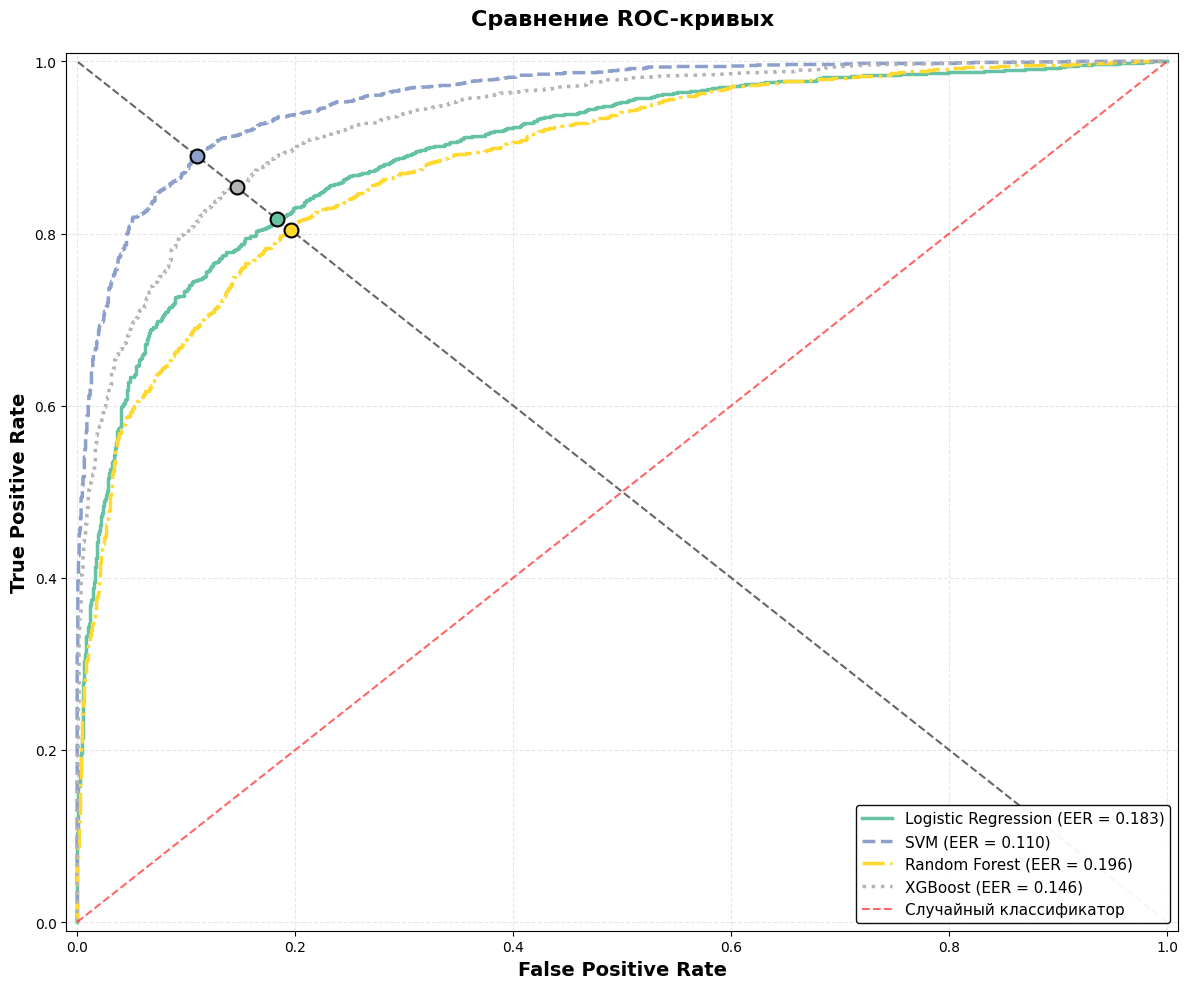

In [27]:
models_dict = {
        'Logistic Regression': logreg_test_probas,
        'SVM': svc_test_probas,
        'Random Forest': rf_test_probas,
        'XGBoost': xgb_test_probas
    }
    

results = visualize_eer(
        y_test, 
        models_dict,
        title="Сравнение ROC-кривых"
    )

In [28]:
for model in models_dict:
    results[model]['ROC-AUC'] = roc_auc_score(y_test, models_dict[model])
results

{'Logistic Regression': {'EER': 0.18333333333333338,
  'Threshold': array(0.5838457),
  'ROC-AUC': np.float64(0.8979255243764173)},
 'SVM': {'EER': 0.10952380952380869,
  'Threshold': array(0.58782261),
  'ROC-AUC': np.float64(0.95765341553288)},
 'Random Forest': {'EER': 0.1958333333333321,
  'Threshold': array(0.49738525),
  'ROC-AUC': np.float64(0.8846811224489796)},
 'XGBoost': {'EER': 0.14642857142857146,
  'Threshold': array(0.56509),
  'ROC-AUC': np.float64(0.9326504039115646)}}

### 3.2. Accuracy

In [29]:
models_dict = {
        'Logistic Regression': logreg_test_predictions,
        'SVM': svc_test_predictions,
        'Random Forest': rf_test_predictions,
        'XGBoost': xgb_test_predictions
    }

for model in models_dict:
    results[model]['Accuracy'] = accuracy_score(y_test, models_dict[model])

In [30]:
print("="*71)
print(f"{'Model':<25} {'EER':<10} {'AUC':<10} {'Threshold':<10} {'Accuracy':<10}")
print("="*71)
for model in results:
    print(f"{model:<25} {results[model]['EER']:<10.4f} {results[model]['ROC-AUC']:<10.4f} {results[model]['Threshold']:<10.4f} {results[model]['Accuracy']:<10.4f}")
print("="*71)

Model                     EER        AUC        Threshold  Accuracy  
Logistic Regression       0.1833     0.8979     0.5838     0.8152    
SVM                       0.1095     0.9577     0.5878     0.8798    
Random Forest             0.1958     0.8847     0.4974     0.7949    
XGBoost                   0.1464     0.9327     0.5651     0.8536    


### 3.3. Доля распознанных дипфейков по TTS-моделям

In [31]:
def visualize_detection_rates(test_df, model_names, figsize=(12, 6)):
    tts_df = test_df[test_df['tts_model'].notna()]
    tts_models = sorted(tts_df['tts_model'].unique())
    
    detection_rates = {}
    
    for model_name in model_names:
        detection_rates[model_name] = []
        
        for tts_model in tts_models:
            df_subset = tts_df[tts_df['tts_model'] == tts_model]
            rate = df_subset[model_name].sum() / len(df_subset) * 100 if len(df_subset) > 0 else 0
            detection_rates[model_name].append(rate)
    
    n_models = len(detection_rates)
    n_tts = len(tts_models)
    
    x = np.arange(n_tts)
    width = 0.8 / n_models
    
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = plt.cm.Set2(np.linspace(0, 1, n_models))
    
    for i, (model_name, rates) in enumerate(detection_rates.items()):
        offset = (i - n_models/2 + 0.5) * width
        bars = ax.bar(x + offset, rates, width, 
                      label=model_name, color=colors[i], edgecolor='black')
        
        for bar, rate in zip(bars, rates):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                   f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)
    
    ax.set_xlabel('TTS Модели', fontsize=12, fontweight='bold')
    ax.set_ylabel('Доля обнаруженных дипфейков (%)', fontsize=12, fontweight='bold')
    ax.set_title('Эффективность детектирования по TTS-моделям', 
                fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(tts_models, rotation=0, fontsize=11)
    ax.set_ylim(0, 105)
    ax.legend(title='Модели детектирования', fontsize=10, title_fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, linewidth=1)
    
    plt.tight_layout()
    plt.show()
    
    return detection_rates, tts_models

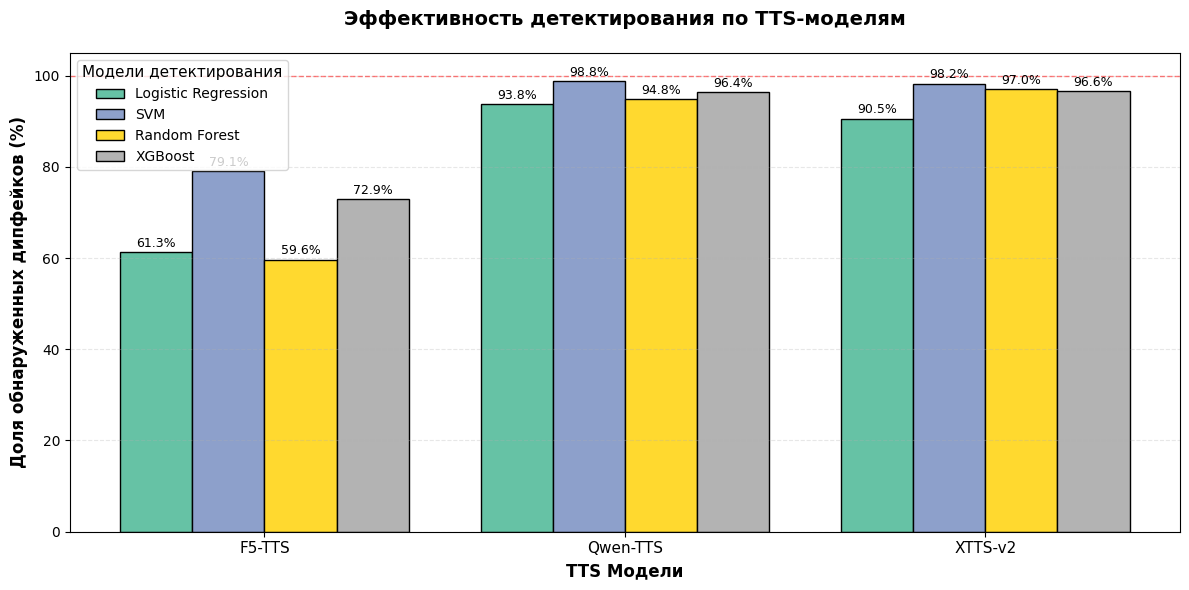

In [32]:
test_df['Logistic Regression'] = logreg_test_predictions
test_df['SVM'] = svc_test_predictions
test_df['Random Forest'] = rf_test_predictions
test_df['XGBoost'] = xgb_test_predictions

model_names = ['Logistic Regression', 'SVM', 'Random Forest', 'XGBoost']
visualize_detection_rates(test_df, model_names);